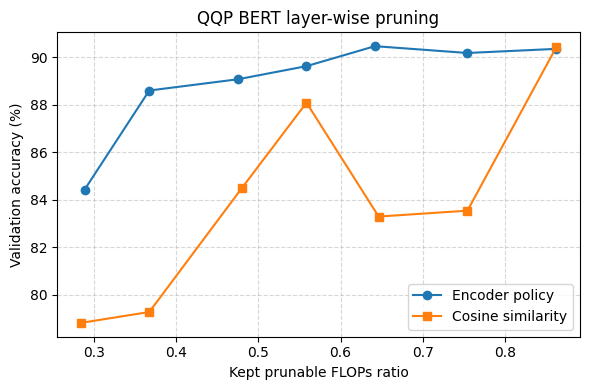

In [3]:
import json
import matplotlib.pyplot as plt

# 根据你机器上的实际路径改一下
ENCODER_JSON = "./checkpoints_qqp_bert_layer_knapsack/qqp_bert_layer_results.json"
COSINE_JSON  = "./checkpoints_qqp_bert_layer_cosine/qqp_bert_layer_cosine_results.json"

def load_curve(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    xs, ys = [], []
    for r in data["ratios"]:
        # 只画有 finetune 过的点
        if "best_val_acc" not in r:
            continue
        x = r["actual_ratio_prunable_mask"]   # 实际保留的 prunable 比例
        y = r["best_val_acc"] * 100.0         # 转成百分比
        xs.append(x)
        ys.append(y)

    # 按 ratio 从小到大排序，画出来更好看
    xs, ys = zip(*sorted(zip(xs, ys)))
    return xs, ys

x_enc, y_enc = load_curve(ENCODER_JSON)
x_cos, y_cos = load_curve(COSINE_JSON)

plt.figure(figsize=(6, 4))
plt.plot(x_enc, y_enc, marker="o", label="Encoder policy")
plt.plot(x_cos, y_cos, marker="s", label="Cosine similarity")

plt.xlabel("Kept prunable FLOPs ratio")
plt.ylabel("Validation accuracy (%)")
plt.title("QQP BERT layer-wise pruning")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("qqp_bert_ratio_vs_acc.png", dpi=200)
plt.show()


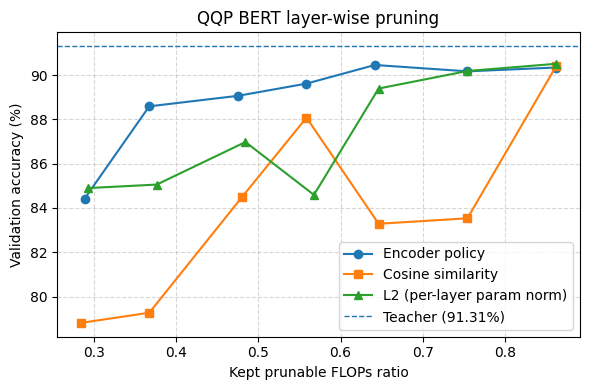

In [2]:
import json
import matplotlib.pyplot as plt

# 根据你机器上的实际路径改一下
ENCODER_JSON = "./checkpoints_qqp_bert_layer_knapsack/qqp_bert_layer_results.json"
COSINE_JSON  = "./checkpoints_qqp_bert_layer_cosine/qqp_bert_layer_cosine_results.json"
L1_JSON      = "./checkpoints_qqp_bert_layer_l2/qqp_bert_layer_l2_results.json"  # <- 这里换成你L1结果的json

TEACHER_ACC = 91.31  # teacher 验证集精度 (%)

def load_curve(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    xs, ys = [], []
    for r in data["ratios"]:
        # 只画有 finetune 过的点
        if "best_val_acc" not in r:
            continue
        x = r["actual_ratio_prunable_mask"]   # 实际保留的 prunable 比例
        y = r["best_val_acc"] * 100.0         # 转成百分比
        xs.append(x)
        ys.append(y)

    # 如果没有任何点，避免 zip 报错
    if not xs:
        return [], []

    # 按 ratio 从小到大排序，画出来更好看
    xs, ys = zip(*sorted(zip(xs, ys)))
    return xs, ys


x_enc, y_enc = load_curve(ENCODER_JSON)
x_cos, y_cos = load_curve(COSINE_JSON)
x_l1,  y_l1  = load_curve(L1_JSON)

plt.figure(figsize=(6, 4))

if x_enc:
    plt.plot(x_enc, y_enc, marker="o", label="Encoder policy")
if x_cos:
    plt.plot(x_cos, y_cos, marker="s", label="Cosine similarity")
if x_l1:
    plt.plot(x_l1,  y_l1,  marker="^", label="L2 (per-layer param norm)")

# teacher 精度虚线天花板
plt.axhline(y=TEACHER_ACC, linestyle="--", linewidth=1.0, label=f"Teacher ({TEACHER_ACC:.2f}%)")

plt.xlabel("Kept prunable FLOPs ratio")
plt.ylabel("Validation accuracy (%)")
plt.title("QQP BERT layer-wise pruning")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("qqp_bert_ratio_vs_acc_with_l2.png", dpi=200)
plt.show()


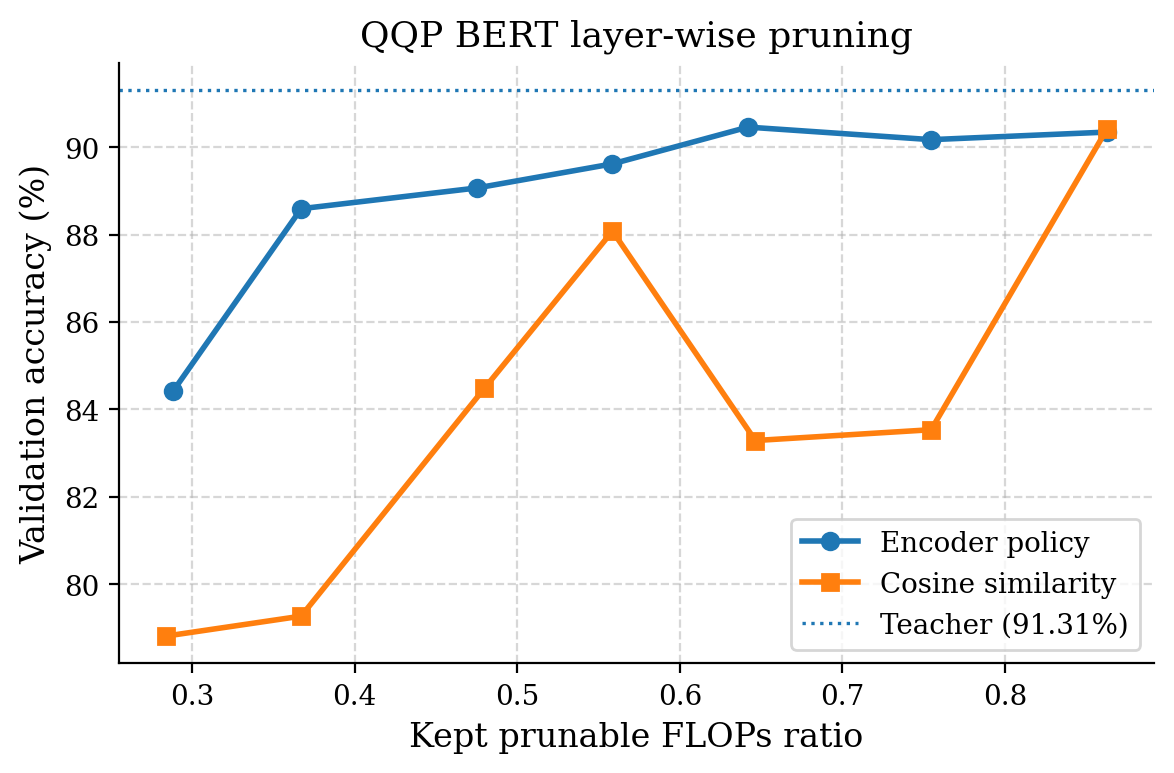

In [13]:
import json
import matplotlib.pyplot as plt

# 根据你机器上的实际路径改一下
ENCODER_JSON = "./checkpoints_qqp_bert_layer_knapsack/qqp_bert_layer_results.json"
COSINE_JSON  = "./checkpoints_qqp_bert_layer_cosine/qqp_bert_layer_cosine_results.json"

def load_curve(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    xs, ys = [], []
    for r in data["ratios"]:
        # 只画有 finetune 过的点
        if "best_val_acc" not in r:
            continue
        x = r["actual_ratio_prunable_mask"]   # 实际保留的 prunable 比例
        y = r["best_val_acc"] * 100.0         # 转成百分比
        xs.append(x)
        ys.append(y)

    # 按 ratio 从小到大排序，画出来更好看
    xs, ys = zip(*sorted(zip(xs, ys)))
    return xs, ys

x_enc, y_enc = load_curve(ENCODER_JSON)
x_cos, y_cos = load_curve(COSINE_JSON)

plt.figure(figsize=(6, 4))
plt.plot(x_enc, y_enc, marker="o", label="Encoder policy")
plt.plot(x_cos, y_cos, marker="s", label="Cosine similarity")

# ===== 在这里加一条 teacher 天花板线 =====
teacher_acc = 91.31
plt.axhline(teacher_acc, linestyle=":", linewidth=1.2, label=f"Teacher ({teacher_acc:.2f}%)")
# 如果想在图里写个文字标注，也可以加下面这句（可选）
# plt.text(0.5, teacher_acc + 0.1, f"Teacher {teacher_acc:.2f}%", transform=plt.gca().get_yaxis_transform())

plt.xlabel("Kept prunable FLOPs ratio")
plt.ylabel("Validation accuracy (%)")
plt.title("QQP BERT layer-wise pruning")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("qqp_bert_ratio_vs_acc.png", dpi=200)
plt.show()



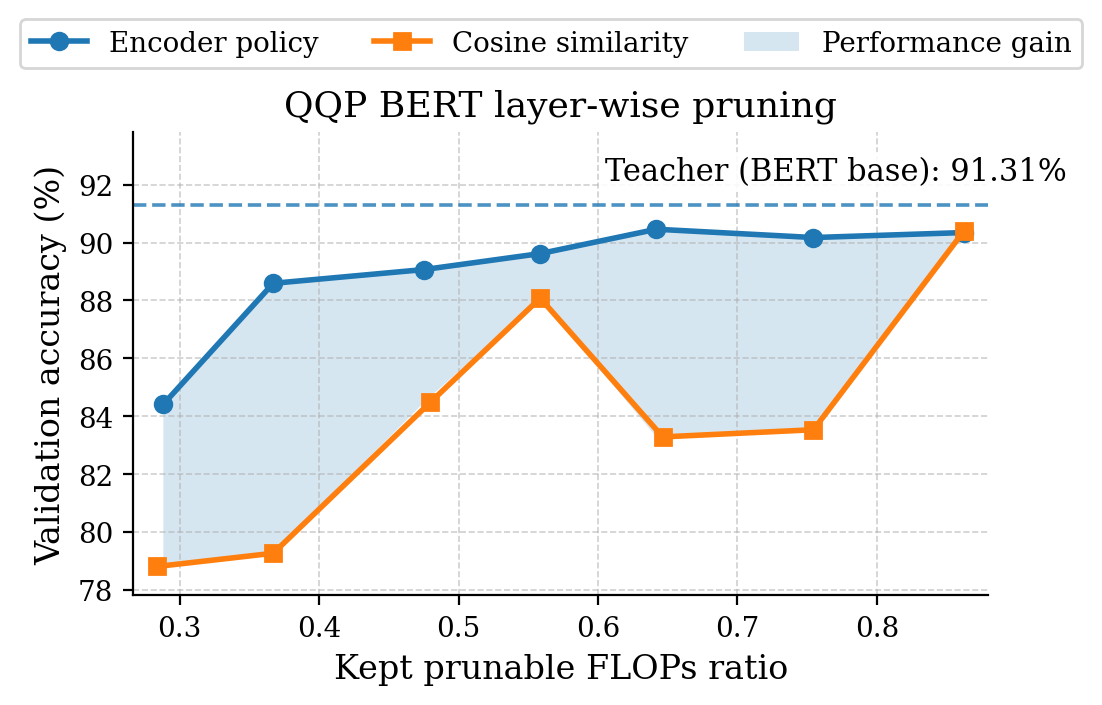

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

ENCODER_JSON = "./checkpoints_qqp_bert_layer_knapsack/qqp_bert_layer_results.json"
COSINE_JSON  = "./checkpoints_qqp_bert_layer_cosine/qqp_bert_layer_cosine_results.json"

TEACHER_ACC = 91.31  # teacher 精度天花板

plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["lines.markersize"] = 6
plt.rcParams["legend.fontsize"] = 10


def load_curve(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    xs, ys = [], []
    for r in data["ratios"]:
        if "best_val_acc" not in r:
            continue
        xs.append(r["actual_ratio_prunable_mask"])
        ys.append(r["best_val_acc"] * 100.0)

    xs, ys = zip(*sorted(zip(xs, ys)))
    return np.array(xs), np.array(ys)


x_enc, y_enc = load_curve(ENCODER_JSON)
x_cos, y_cos = load_curve(COSINE_JSON)

fig, ax = plt.subplots(figsize=(5.5, 3.6))

# 两条曲线
ln1, = ax.plot(x_enc, y_enc, marker="o", label="Encoder policy", zorder=3)
ln2, = ax.plot(x_cos, y_cos, marker="s", label="Cosine similarity", zorder=3)

# ===== 只在 encoder > cosine 的区间填阴影 =====
mask = y_enc > y_cos
if mask.any():
    ax.fill_between(
        x_enc,
        y_cos,
        y_enc,
        where=mask,
        interpolate=True,   # 边界插值，阴影连续
        alpha=0.18,
        label="Performance gain",
        zorder=1,
    )

# teacher 虚线
ax.axhline(TEACHER_ACC, linestyle="--", linewidth=1.3, alpha=0.8, zorder=2)

# y 轴范围
y_min = min(y_enc.min(), y_cos.min()) - 1
y_max = TEACHER_ACC + 2.5
ax.set_ylim(y_min, y_max)

# Teacher 文本摆在虚线上方一点，带白底，不和虚线/图例打架
x_min, x_max = ax.get_xlim()
x_text = x_min + 0.55 * (x_max - x_min)
ax.text(
    x_text,
    TEACHER_ACC + 0.6,
    f"Teacher (BERT base): {TEACHER_ACC:.2f}%",
    ha="left",
    va="bottom",
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=1.5),
)

# 坐标轴&网格
ax.set_xlabel("Kept prunable FLOPs ratio")
ax.set_ylabel("Validation accuracy (%)")
ax.set_title("QQP BERT layer-wise pruning")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.margins(x=0.03)

# ===== 图例放在整张图最上方（figure 级别），完全不遮挡内容 =====
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=3,
    frameon=True,
)

# 给上方图例留一点空间即可
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("qqp_bert_ratio_vs_acc_beautified.png", dpi=220)
plt.show()


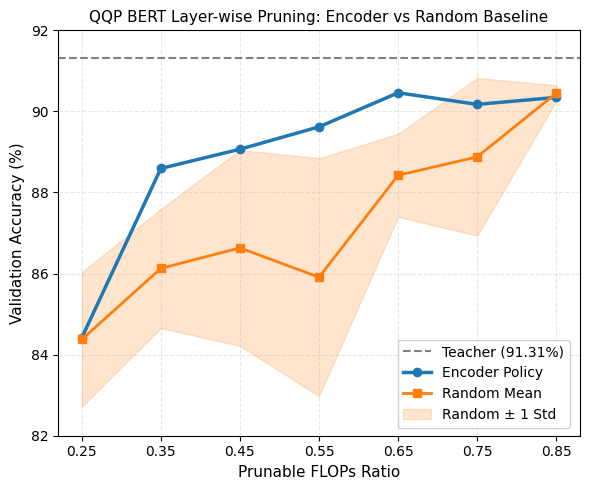

In [28]:
import json
import os
import math
import statistics as stats
import matplotlib.pyplot as plt

ENCODER_JSON = "./checkpoints_qqp_bert_layer_knapsack/qqp_bert_layer_results.json"
RANDOM_JSON  = "./checkpoints_qqp_bert_layer_random/qqp_bert_layer_random_results.json"

# ===== 1. 读取 encoder 结果 =====
with open(ENCODER_JSON, "r", encoding="utf-8") as f:
    enc_data = json.load(f)

enc_ratios_raw = enc_data.get("ratios", [])

x_ratios = []
enc_accs = []   # encoder best_val_acc * 100

for r in enc_ratios_raw:
    ratio = float(r.get("target_ratio_prunable", r.get("target_ratio", 0.0)))
    if "best_val_acc" not in r:
        # 有可能你没开 --do_finetune，这里直接跳过
        continue
    acc = float(r["best_val_acc"]) * 100.0
    x_ratios.append(ratio)
    enc_accs.append(acc)

# 按 ratio 排个序，方便画折线
enc_pairs = sorted(zip(x_ratios, enc_accs), key=lambda t: t[0])
x_ratios_enc, enc_accs_sorted = zip(*enc_pairs) if enc_pairs else ([], [])

# ===== 2. 读取 random baseline 结果 =====
with open(RANDOM_JSON, "r", encoding="utf-8") as f:
    rnd_data = json.load(f)

rnd_ratios_raw = rnd_data.get("ratios", [])

x_ratios_rnd = []
rnd_mean_accs = []
rnd_std_accs = []

for ratio_entry in rnd_ratios_raw:
    ratio = float(ratio_entry.get("target_ratio_prunable", 0.0))
    samples = ratio_entry.get("samples", [])

    accs = []
    for s in samples:
        if "best_val_acc" in s:
            accs.append(float(s["best_val_acc"]) * 100.0)

    if not accs:
        # 这个 ratio 没 finetune 的话就跳过
        continue

    mean_acc = sum(accs) / len(accs)
    std_acc = stats.stdev(accs) if len(accs) > 1 else 0.0

    x_ratios_rnd.append(ratio)
    rnd_mean_accs.append(mean_acc)
    rnd_std_accs.append(std_acc)

# 同样按 ratio 排序
rnd_pairs = sorted(zip(x_ratios_rnd, rnd_mean_accs, rnd_std_accs), key=lambda t: t[0])
if rnd_pairs:
    x_ratios_rnd_sorted, rnd_mean_sorted, rnd_std_sorted = zip(*rnd_pairs)
else:
    x_ratios_rnd_sorted, rnd_mean_sorted, rnd_std_sorted = ([], [], [])

# ===== 3. 画图 =====

plt.figure(figsize=(6, 5))

# Teacher “天花板”
teacher_acc = 91.31
plt.axhline(teacher_acc, linestyle="--", linewidth=1.5, color="gray", label="Teacher (91.31%)")

# Encoder 折线（蓝色、加粗）
if x_ratios_enc:
    plt.plot(
        x_ratios_enc,
        enc_accs_sorted,
        marker="o",
        linewidth=2.5,
        color="#1f77b4",
        label="Encoder Policy"
    )

# Random mean 折线 + 阴影带（橙色）
if x_ratios_rnd_sorted:
    x_r = list(x_ratios_rnd_sorted)
    y_mean = list(rnd_mean_sorted)
    y_std = list(rnd_std_sorted)

    upper = [m + s for m, s in zip(y_mean, y_std)]
    lower = [m - s for m, s in zip(y_mean, y_std)]

    plt.plot(
        x_r,
        y_mean,
        marker="s",
        linewidth=2,
        color="#ff7f0e",
        label="Random Mean"
    )
    plt.fill_between(
        x_r,
        lower,
        upper,
        color="#ff7f0e",
        alpha=0.2,
        label="Random ± 1 Std"
    )

plt.xlabel("Prunable FLOPs Ratio", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.title("QQP BERT Layer-wise Pruning: Encoder vs Random Baseline", fontsize=11)

# x 轴刻度做得规整一点
if x_ratios_enc or x_ratios_rnd_sorted:
    all_x = sorted(set(list(x_ratios_enc) + list(x_ratios_rnd_sorted)))
    plt.xticks(all_x, [f"{x:.2f}" for x in all_x])

# plt.ylim(80, 95)   # 你可以按需要调整一下上下限
###########
import math

all_vals = [teacher_acc]

# Encoder
all_vals.extend(enc_accs_sorted)

# Random mean
all_vals.extend(rnd_mean_sorted)

# Random band 上下界都要算进去
all_vals.extend([m + s for m, s in zip(rnd_mean_sorted, rnd_std_sorted)])  # 上界
all_vals.extend([m - s for m, s in zip(rnd_mean_sorted, rnd_std_sorted)])  # 下界  <-- 新增

y_min = min(all_vals)
y_max = max(all_vals)

margin = 0.5  # 或者 1.0，看你喜好
y_lower = max(0.0, math.floor(y_min - margin))
y_upper = min(100.0, math.ceil(y_max + margin))

plt.ylim(y_lower, y_upper)


###############

plt.grid(alpha=0.3, linestyle="--")

# 图例放在图外，避免和曲线/阴影重叠
# plt.legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     borderaxespad=0.
# )

plt.legend(
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),  # (x, y) in axes coords
    borderaxespad=0.0,
    frameon=True,
    framealpha=0.9,
)



plt.tight_layout()
plt.savefig("qqp_encoder_vs_random.pdf", bbox_inches="tight")
plt.show()


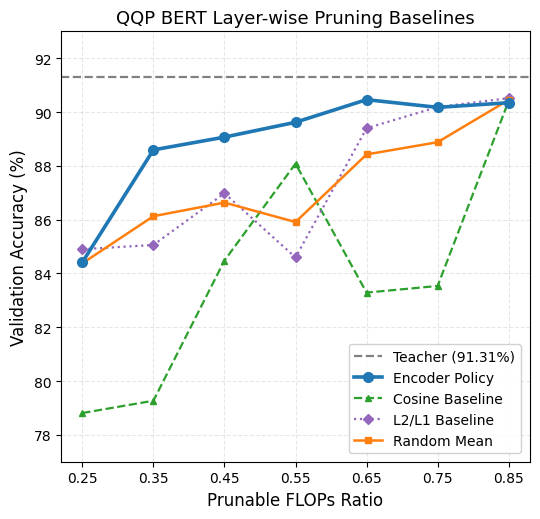

In [33]:
import json
import statistics as stats
import math
import matplotlib.pyplot as plt

ENCODER_JSON = "./checkpoints_qqp_bert_layer_knapsack/qqp_bert_layer_results.json"
RANDOM_JSON  = "./checkpoints_qqp_bert_layer_random/qqp_bert_layer_random_results.json"
COSINE_JSON  = "./checkpoints_qqp_bert_layer_cosine/qqp_bert_layer_cosine_results.json"
L1_JSON      = "./checkpoints_qqp_bert_layer_l2/qqp_bert_layer_l2_results.json"

teacher_acc = 91.31  # teacher 天花板


def load_single_baseline(path, key_name="best_val_acc"):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    ratios_raw = data.get("ratios", [])
    xs, ys = [], []
    for r in ratios_raw:
        ratio = float(r.get("target_ratio_prunable", r.get("target_ratio", 0.0)))
        if key_name not in r:
            continue
        acc = float(r[key_name]) * 100.0
        xs.append(ratio)
        ys.append(acc)
    pairs = sorted(zip(xs, ys), key=lambda t: t[0])
    return ([], []) if not pairs else tuple(map(list, zip(*pairs)))


def load_random_baseline(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    ratios_raw = data.get("ratios", [])

    xs, mean_accs, std_accs = [], [], []
    for ratio_entry in ratios_raw:
        ratio = float(ratio_entry.get("target_ratio_prunable", 0.0))
        accs = [
            float(s["best_val_acc"]) * 100.0
            for s in ratio_entry.get("samples", [])
            if "best_val_acc" in s
        ]
        if not accs:
            continue
        mean_acc = sum(accs) / len(accs)
        std_acc = stats.stdev(accs) if len(accs) > 1 else 0.0
        xs.append(ratio)
        mean_accs.append(mean_acc)
        std_accs.append(std_acc)
    pairs = sorted(zip(xs, mean_accs, std_accs), key=lambda t: t[0])
    return ([], [], []) if not pairs else tuple(map(list, zip(*pairs)))


# ===== 1. 读取所有 baseline =====

x_enc, y_enc = load_single_baseline(ENCODER_JSON)
x_cos, y_cos = load_single_baseline(COSINE_JSON)
x_l1,  y_l1  = load_single_baseline(L1_JSON)
x_rnd, y_rnd_mean, y_rnd_std = load_random_baseline(RANDOM_JSON)

all_x = sorted(set(x_enc + x_cos + x_l1 + x_rnd))

# 用于自动设 y 轴上下界
all_acc_values = [teacher_acc]
for arr in [y_enc, y_cos, y_l1, y_rnd_mean]:
    all_acc_values.extend(arr)

y_min = min(all_acc_values) if all_acc_values else 80.0
y_max = max(all_acc_values) if all_acc_values else 95.0

# 留一点 margin
y_margin = 1.0
y_lower = math.floor(y_min - y_margin)
y_upper = math.ceil(y_max + y_margin)

# ===== 2. 画图 =====

plt.figure(figsize=(5.5, 5.3))

# Teacher 天花板（灰色虚线）
plt.axhline(
    teacher_acc,
    linestyle="--",
    linewidth=1.6,
    color="gray",
    label="Teacher (91.31%)",
)

# Encoder：主角 —— 粗蓝线 + 大圆点
if x_enc:
    plt.plot(
        x_enc,
        y_enc,
        color="#1f77b4",
        marker="o",
        linewidth=2.6,
        markersize=7,
        label="Encoder Policy",
        zorder=4,
    )

# Cosine baseline：细绿虚线 + 小三角
if x_cos:
    plt.plot(
        x_cos,
        y_cos,
        color="#2ca02c",
        marker="^",
        markersize=5,
        linewidth=1.6,
        linestyle="--",
        label="Cosine Baseline",
        zorder=2,
    )

# L2/L1 baseline：细紫点划线 + 小菱形
if x_l1:
    plt.plot(
        x_l1,
        y_l1,
        color="#9467bd",
        marker="D",
        markersize=5,
        linewidth=1.6,
        linestyle=":",
        label="L2/L1 Baseline",
        zorder=2,
    )

# Random mean + 阴影带：橙色方块线 + 浅橙阴影
# if x_rnd:
#     upper = [m + s for m, s in zip(y_rnd_mean, y_rnd_std)]
#     lower = [m - s for m, s in zip(y_rnd_mean, y_rnd_std)]

#     # 阴影先画（在下面）
#     plt.fill_between(
#         x_rnd,
#         lower,
#         upper,
#         color="#ff7f0e",
#         alpha=0.18,
#         label="Random ± 1 Std",
#         zorder=1,
#     )

    # mean 线稍细一点，颜色比阴影略深
    plt.plot(
        x_rnd,
        y_rnd_mean,
        color="#ff7f0e",
        marker="s",
        markersize=5,
        linewidth=1.8,
        label="Random Mean",
        zorder=3,
    )

# ===== 3. 美化坐标 / 图例 =====

plt.xlabel("Prunable FLOPs Ratio", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("QQP BERT Layer-wise Pruning Baselines", fontsize=13)

if all_x:
    plt.xticks(all_x, [f"{x:.2f}" for x in all_x])

plt.ylim(y_lower, y_upper)
plt.grid(alpha=0.3, linestyle="--")

# # 图例仍然放在右侧，避免和图形重叠
# plt.legend(
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     borderaxespad=0.0,
# )
plt.legend(
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),  # (x, y) in axes coords
    borderaxespad=0.0,
    frameon=True,
    framealpha=0.9,
)


plt.tight_layout()
plt.savefig("baselines_vs_encoder_qqp.pdf", bbox_inches="tight")
plt.show()
